### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from _03_01_function_to_normalize_sgrna_lfc import *

In [21]:
lfc_data = pd.read_csv("../data/sgrna_lfc_data/jacquere_data/jacquereA375lfc.csv", sep =',')
lfc_data = lfc_data.rename(columns={lfc_data.columns[1]: 'spacer', lfc_data.columns[6]: 'gene'})
# Select only the 'spacer' and 'sgRNA_lfc' columns
lfc_data = lfc_data[['spacer', 'sgRNA_lfc']]
print(lfc_data.shape)

lfc_data.head(25)

(65796, 2)


,spacer,sgRNA_lfc
0,AAAAAAGAAAGGATACGTCC,-0.770787
1,AAAAACAGCTGATGAAACCT,-0.323128
2,AAAAACCTGGGAAAGATATA,0.270047
3,AAAAAGAGGCGGCATTACAG,-0.251598
4,AAAAAGATAGATGTGCTAAA,-3.443730
5,AAAAAGATGGAAAACTATGC,-0.877070
6,AAAAAGCCACCAGCCCAGGA,1.108381
7,AAAAAGCCTGGATAACGGAA,1.005087
8,AAAAAGCTGAAGCAGAGTCA,-3.258720
9,AAAAAGGAGAATGTAGTGGT,0.851895


In [22]:
# import library data
library_data = pd.read_csv("../data/library_data/Jacquere_PerGuideAnnotations_Quota4.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
display(library_data)

,sgRNA,spacer,gene
0,sgA1BG_1,ACAGTCACCGAGCTCCTCAA,A1BG
1,sgA1BG_2,GTGGAGTGGACTTCCAGCTA,A1BG
2,sgA1BG_3,GTAGTGACCTCCATCCCCCA,A1BG
3,sgA1BG_4,ACTGGCGCCATCGAGAGCCA,A1BG
4,sgA1CF_1,TGCTAGGGTGACTTCAATGG,A1CF
...,...,...,...
78779,sgZZEF1_4,GGTGTGATGAGATTGCCCCC,ZZEF1
78780,sgZZZ3_1,ACAAGGAGTCAGTAGAACAG,ZZZ3
78781,sgZZZ3_2,CCTGCCTCCAGGCTGATATT,ZZZ3
78782,sgZZZ3_3,AGTAAGTAAACCACCCTCAG,ZZZ3


In [23]:
lfc = pd.merge(lfc_data, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="gene")

# Remove duplicate rows
lfc = lfc[~lfc.index.duplicated(keep='first')]
lfc = lfc.sort_index(level='sgRNA')

lfc = lfc.dropna()
print(f"DataFrame shape after dropping NaN values: {lfc.shape}")
lfc

DataFrame shape after dropping NaN values: (60258, 1)


sgRNA_lfc
sgRNA    spacer               gene           
sgA1BG_2 GTGGAGTGGACTTCCAGCTA A1BG   0.117657
sgA1BG_3 GTAGTGACCTCCATCCCCCA A1BG  -0.419929
sgA1BG_4 ACTGGCGCCATCGAGAGCCA A1BG   0.319926
sgA1CF_2 ATGACTCTCATACTCCACGA A1CF  -1.077963
sgA1CF_3 GAAGACAGGAGCTCCAAGGT A1CF   0.752200
...                                       ...
NaN      TTGTACCCATATAAAGTCTA NaN    0.207489
         TTGTACTGAATACTTAACAC NaN   -1.718432
         TTGTATCAGAGTAAGATGGA NaN   -0.551335
         TTGTTGAGAAAGCAGGCGAG NaN   -2.518548
         TTTCGGCTCAGGAAGAGCCA NaN    0.641346

[60258 rows x 1 columns]

In [24]:
# Center LFCs using non-essential guides
non_essential_mask = ~lfc.index.get_level_values(2).isin(['NO_SITE'])
median_non_essential = lfc[non_essential_mask].median(axis=0)

median_non_essential

sgRNA_lfc   -0.053133
dtype: float64

In [25]:
# Subtract median of non-essential guides for each sample (normalized sgrna LFC)
sgrna_lfc_normalized = lfc - median_non_essential
sgrna_lfc_normalized

sgRNA_lfc
sgRNA    spacer               gene           
sgA1BG_2 GTGGAGTGGACTTCCAGCTA A1BG   0.170791
sgA1BG_3 GTAGTGACCTCCATCCCCCA A1BG  -0.366796
sgA1BG_4 ACTGGCGCCATCGAGAGCCA A1BG   0.373059
sgA1CF_2 ATGACTCTCATACTCCACGA A1CF  -1.024830
sgA1CF_3 GAAGACAGGAGCTCCAAGGT A1CF   0.805334
...                                       ...
NaN      TTGTACCCATATAAAGTCTA NaN    0.260622
         TTGTACTGAATACTTAACAC NaN   -1.665298
         TTGTATCAGAGTAAGATGGA NaN   -0.498202
         TTGTTGAGAAAGCAGGCGAG NaN   -2.465415
         TTTCGGCTCAGGAAGAGCCA NaN    0.694479

[60258 rows x 1 columns]

In [26]:
# scaled sgRNA log fold change by centering around the median LFC of guides targeting essential genes
lfc_norm_scaled, list_common_essential = scale_essential(sgrna_lfc_normalized)
lfc_norm_scaled

Scale factor:  3.1148237145467172


sgRNA_lfc
sgRNA    spacer               gene           
sgA1BG_2 GTGGAGTGGACTTCCAGCTA A1BG   0.054832
sgA1BG_3 GTAGTGACCTCCATCCCCCA A1BG  -0.117758
sgA1BG_4 ACTGGCGCCATCGAGAGCCA A1BG   0.119769
sgA1CF_2 ATGACTCTCATACTCCACGA A1CF  -0.329017
sgA1CF_3 GAAGACAGGAGCTCCAAGGT A1CF   0.258549
...                                       ...
NaN      TTGTACCCATATAAAGTCTA NaN    0.083671
         TTGTACTGAATACTTAACAC NaN   -0.534636
         TTGTATCAGAGTAAGATGGA NaN   -0.159945
         TTGTTGAGAAAGCAGGCGAG NaN   -0.791510
         TTTCGGCTCAGGAAGAGCCA NaN    0.222959

[60258 rows x 1 columns]

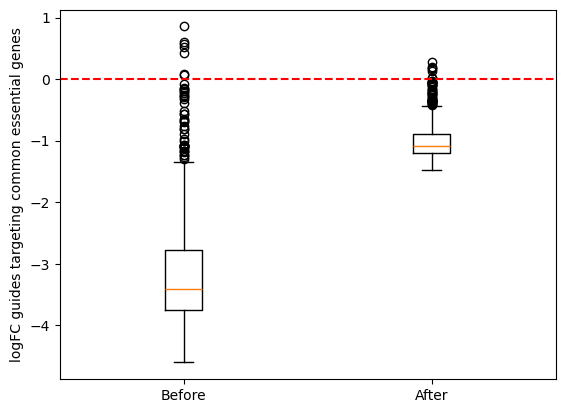

In [27]:
# check whether the normalization works (the median of lfc data should be around 0)
sanity_check_scale_essential(sgrna_lfc_normalized, lfc_norm_scaled, list_common_essential)

In [28]:
lfc_norm_scaled_avg = mean_row(lfc_norm_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_2,GTGGAGTGGACTTCCAGCTA,A1BG,0.054832
1,sgA1BG_3,GTAGTGACCTCCATCCCCCA,A1BG,-0.117758
2,sgA1BG_4,ACTGGCGCCATCGAGAGCCA,A1BG,0.119769
3,sgA1CF_2,ATGACTCTCATACTCCACGA,A1CF,-0.329017
4,sgA1CF_3,GAAGACAGGAGCTCCAAGGT,A1CF,0.258549
...,...,...,...,...
60253,NaN,TTGTACCCATATAAAGTCTA,NaN,0.083671
60254,NaN,TTGTACTGAATACTTAACAC,NaN,-0.534636
60255,NaN,TTGTATCAGAGTAAGATGGA,NaN,-0.159945
60256,NaN,TTGTTGAGAAAGCAGGCGAG,NaN,-0.791510


In [29]:
lfc_norm_scaled_avg.to_csv("../data/sgrna_lfc_data/output_normalized/jacquere_normalized_lfc.csv", index=False)